In [21]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_bloch_vector
from qiskit.circuit.library.standard_gates import ZGate

## IV. Programmes quantiques simples : L'algorithme de Grover

Ces explications nous permettent donc de comprendre que la construction d'une fonction en informatique quantique, revient essentiellement à **trouver un ensemble de rotations et de reflexions** du vecteur d'état (grâce à des portes quantiques de base), afin de le faire **pointer dans une direction particulière**, exploitable par la suite.

Pour donner un exemple d'une construction de fonction en informatique quantique, nous allons nous inspirer des problèmes NP, dont l'algorithme de résolution est accélérée quadratiquement par l'arrivée de l'informatique quantique, et tout particulièrement par le développement de l'**algorithme de Grover** en 1996.

### IV.A. Rappel sur la complexité et les problèmes NP

Pour rappel, usuellement on classe les algorithmes selon leur complexité en temps (nombre d'opérations) ou en espace, ce qui nous permet de comparer les algorithmes selon leurs "besoins" en ressources, comme le temps de calcul ou l'espace mémoire.

Ainsi, lors de l'optimisation d'un problème, l'une des notions les plus importantes est la complexité en temps en fonction d'une quantité $n$ de données à traiter. 
Dans ce sens, on qualifiera la complexité de chaque algorithme à l'aide des notations de Landau $O$ tel que :
* $O(1)$ : le temps ne dépend pas de la taille de l’entrée
* $O(n)$ : le temps d'execution est linéaire à celui de l'entrée
* $O(n^k)$ : le temps d'execution est polynomiale (quadratique, cubique...)
* $O(2^n), O(n!)$ : le temps d'execution est exponentiel

En effet, tandis qu'un algorithme classique vérifie **successivement** chaque solution $x_i$ ($O(N)$), l'algorithme de Grover les compare **en même temps** pour effectuer $\frac{\pi}{4}\sqrt{N}$ calculs ($O(\sqrt{N})$)

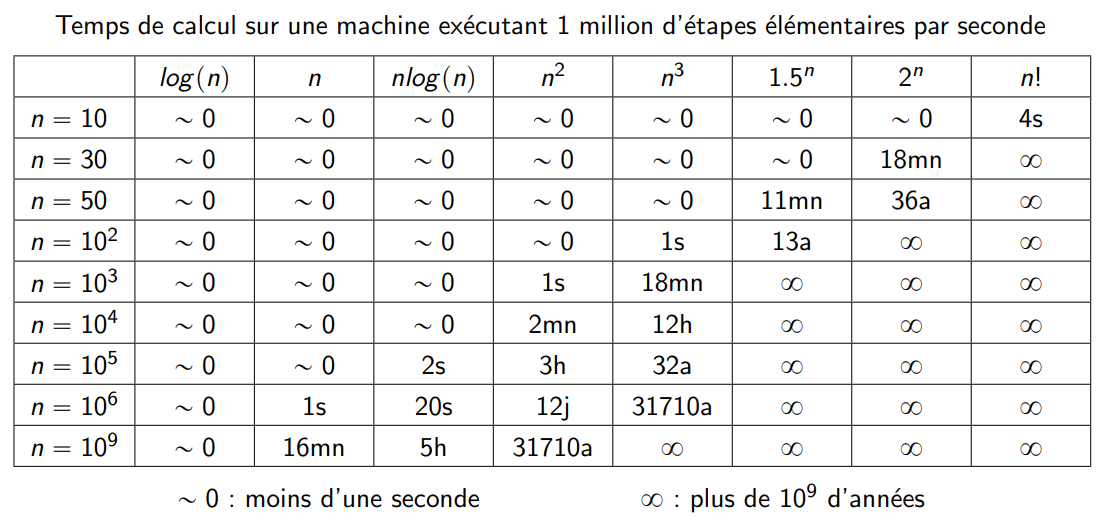

En théorie de la complexité, on distingue généralement deux principaux types de problèmes :
* Les problèmes de décision : *“Existe-t-il … de coût/taille $\le k$ ?”*
* Les problèmes d’optimisation : *“Quel est … de coût minimal ?”*

On peut classer les problèmes de décision dans deux classes :
* Les problèmes P : dont la solution est **calculable** en temps polynomial
* Les problèmes NP : dont la solution est **vérifiable** en temps polynomial

C’est-à-dire qu’un problème P, comme par exemple *"Existe-t-il un chemin de i à j ?"*, peut-être résolu entièrement à l’aide d’un algorithme polynomial (ici en $O(n^2)$).

Mais un problème NP, comme le problème du voyageur de commerce *"Existe-t-il un circuit Hamiltonien de coût $\le k$ ?"*, ne le peut (pour l’instant) pas.

Ainsi, pour résoudre un problème NP, on utilise un vérificateur polynomial, comme par exemple :

In [22]:
def verifier_TSP_decision(graph, cycle, K):

    if cycle[0] != cycle[-1]:
        return False

    unique_nodes = cycle[:-1]
    if len(unique_nodes) != len(set(unique_nodes)):
        return False

    if set(unique_nodes) != set(graph.keys()):
        return False

    cost = 0
    for u, v in zip(cycle, cycle[1:]):
        if v not in graph[u]:
            return False  # arête inexistante
        cost += graph[u][v]

    return cost <= K


qui permet de vérifier si une instance du problème (ici, un cycle de villes) vérifie la question posée.

Pour résoudre ce genre de problèmes, il faut donc vérifier l’ensemble des $2^n$ ou des $n!$ instances successivement, soit utiliser un algorithme en $O(n^2)$ ou en $O(n!)$ (très long à résoudre).

C'est pourquoi, nous allons nous intéresser ici à l'algorithme de Grover, qui plutôt que de vérifier successivement chaque instance ($O(N)$), compare toutes les instances en même temps afin de faire ressortir la solution, après $\frac{\pi}{4}\sqrt{N}$ calculs ($O(\sqrt{N})$).


### IV.B. 

#### IV.B.1) Etape 1 : Superposition

Considérons un vecteur d'état $\left| s \right\rangle$, de taille $n$ qubits, pouvant prendre $N=2^n$ valeurs différentes, soit $N$ états différents.

La première étape sera donc de mettre tous les états en superposition à l'aide de portes Hadamard.

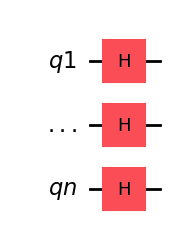

In [23]:
first = QuantumRegister(1, name="q1")
other = QuantumRegister(1, name="...")
last = QuantumRegister(1, name="qn")
Grover = QuantumCircuit(first, other, last)

for i in range (3):
    Grover.h(i)
    
Grover.draw('mpl')

On obtient ainsi un vecteur d'état : $\left| s \right\rangle=\frac{1}{\sqrt{N}}\sum_{i=1}^{N}\left| x_i \right\rangle$.

En d'autres termes, cela signifie que la distribution de probabilité sur toutes les sorties est uniforme : toutes les composantes sont égales, donc les probabilités de chaque sortie sont égales.

Visuellement, pour un vecteur d'état à 3 dimensions, on obtiendrait le vecteur $\left| s \right\rangle$ :

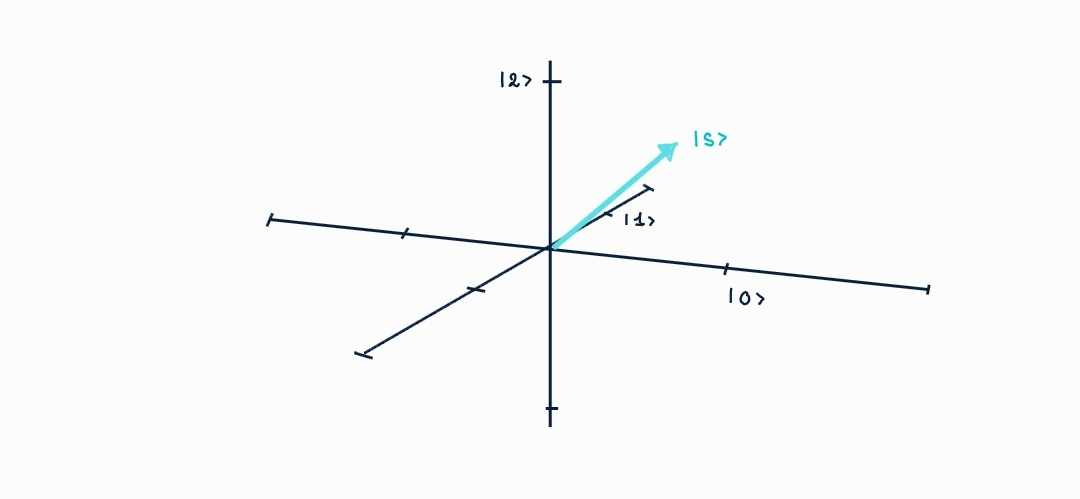

*A noter qu'un vecteur d'état se doit d'avoir $2^n$ composantes. Nous utilisons ici un vecteur d'état à 3 dimensions simplement pour aider à la compréhension de l'algorithme.*

Ici, on prendra comme solution $\left| \omega \right\rangle=\left| 2 \right\rangle=\begin{bmatrix}0 & 0 & 1 \end{bmatrix}$ que l'on marquera en jaune. 

On pourra voir que l'ensemble des opérations se déroule dans le cercle résultant de l'intersection de la sphère avec le plan $(O,\left| \omega \right\rangle,\left| s \right\rangle)$, que ce soit pour un vecteur de dimension $3$ ou $N$.

On peut donc simplifier notre schéma, en gardant sur l'axe des ordonnées la solution $\left| \omega \right\rangle$ et sur l'axe des abscisses, une superposition de l'ensemble des autres solutions $\left| \xi \right\rangle=\frac{1}{\sqrt{N-1}}\sum_{n \neq \omega}\left| n \right\rangle$.

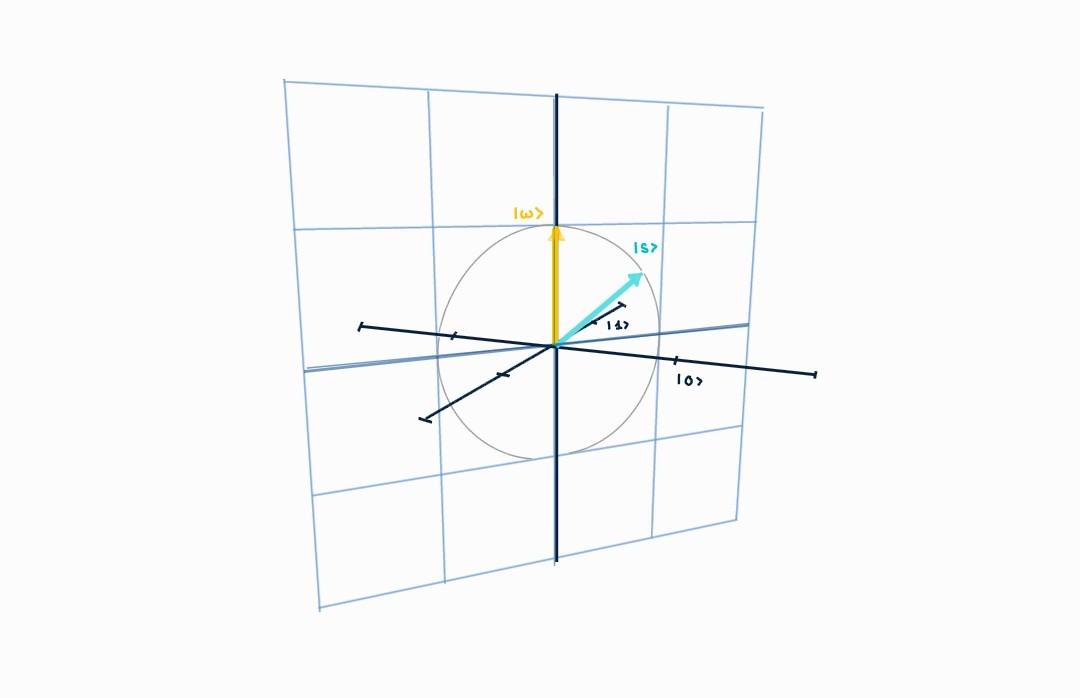

Puisque la composante associée à $\left| \omega \right\rangle$ est égale à $\frac{1}{\sqrt{N}}$, le vecteur $\left| s \right\rangle$ s'éloigne de plus en plus orthogonalement de l'axe $\left| \omega \right\rangle$, plus on augmente le nombre de solutions possible $N$. 

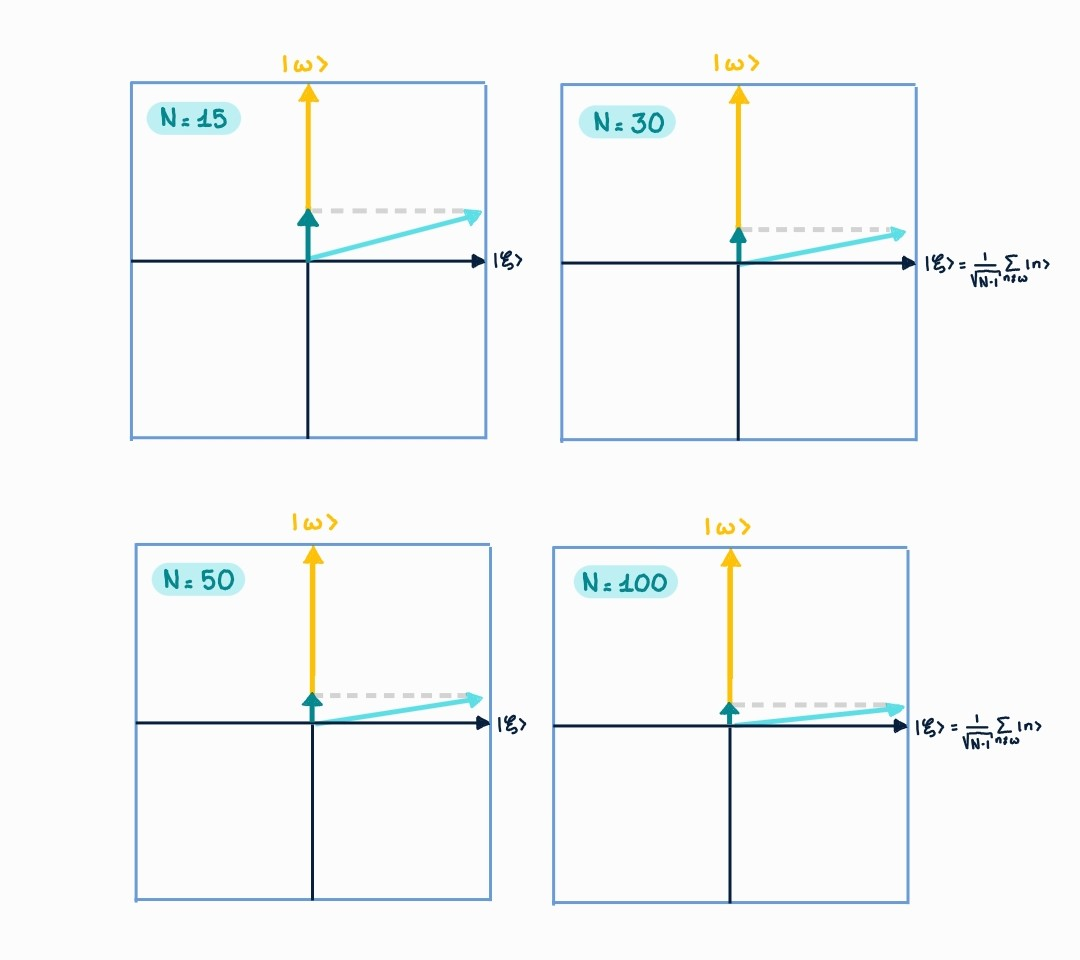

Une mesure que l'on peut donc déjà réaliser est celle de l'angle $\theta$ entre $\left| s \right\rangle$ et $\left| \xi \right\rangle$. 

##### Mesure de l'angle $\theta$ : 

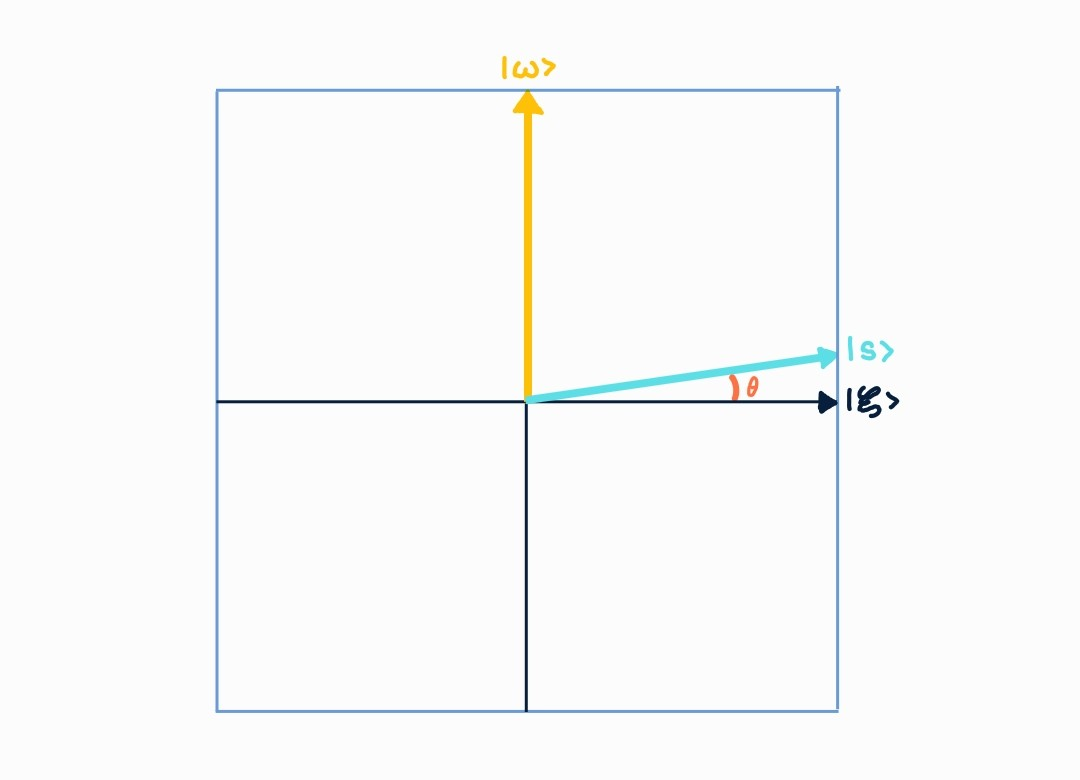

C'est l'angle $\theta$, lié au niveau d'éloignement orthogonal du vecteur d'état $\left| s \right\rangle$ par rapport à la solution $\left| \omega \right\rangle$, qui nous permet d'estimer le nombre d'opérations nécessaires (et donc le temps d'exécution) de l'algorithme de Grover.

Pour calculer cet angle, il suffit de passer par le calcul de l'angle $\alpha$. 

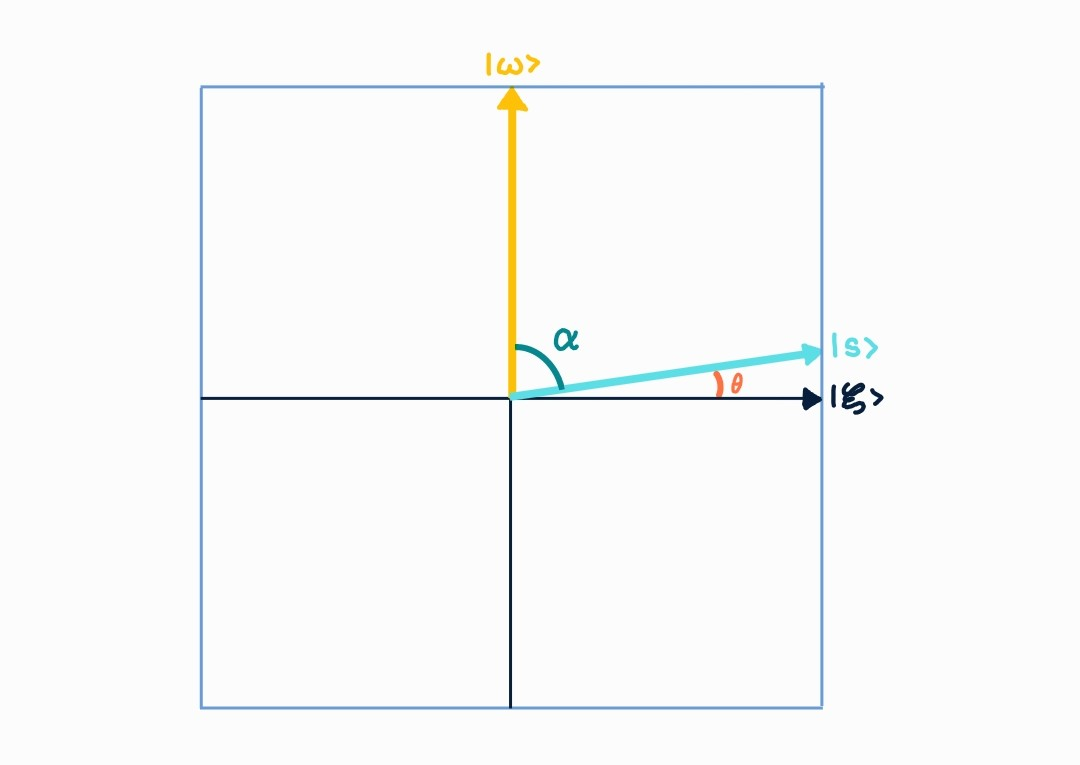

En effet, nous savons que le produit scalaire entre $\left| \omega \right\rangle$ et $\left| s\right\rangle$, que l'on notera $\left| \omega \right\rangle.\left| s\right\rangle\overset{\text{not.}}{=}\left\langle \omega | s \right\rangle$, vérifie :

$$\text{Re}(\left\langle \omega | s \right\rangle)=\left\| \omega \right\|\left\| s \right\|\cos(\alpha)=\cos(\alpha) \quad \text{ car }\, \left\| \omega \right\|=\left\| s \right\|=1$$

Mais, puisque $\left| s\right\rangle=\begin{bmatrix}\frac{1}{\sqrt{N}} & \frac{1}{\sqrt{N}} & \ldots &\frac{1}{\sqrt{N}} \end{bmatrix}^T$ et $\left| \omega \right\rangle=\begin{bmatrix}0 & 0 & \ldots & 0 & 1 & 0 & \ldots & 0 \end{bmatrix}^T$

On peut calculer l'angle $\alpha$ par : $$\cos(\alpha)=\text{Re}(\left\langle \omega | s \right\rangle)=\frac{1}{\sqrt{N}}$$

On peut donc également calculer l'angle $\theta$ entre l'axe $\left| \xi\right\rangle$ et $\left| s\right\rangle$, tel que : $\sin\theta=\cos\alpha=\frac{1}{\sqrt{N}}$

Soit, puisque $\theta$ est très petit : $\theta\simeq\sin\theta=\frac{1}{\sqrt{N}}$

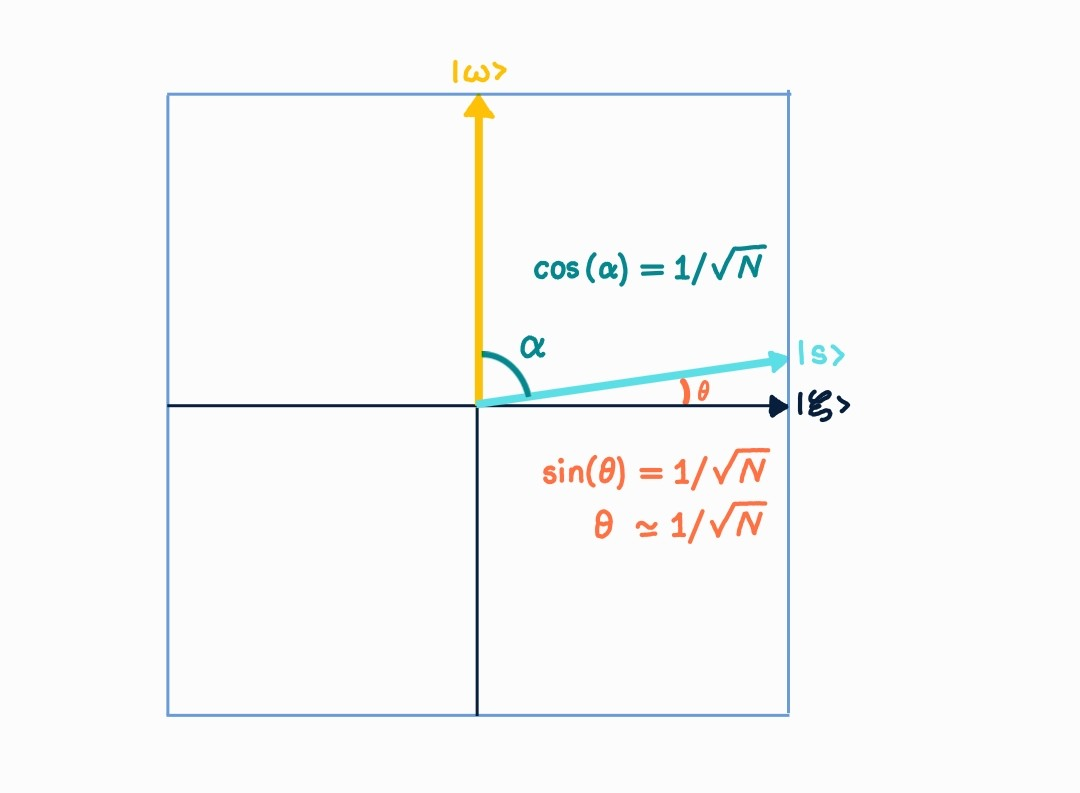

C'est donc cet angle, lié à l'écart entre notre approximation $\left| s\right\rangle$ et la solution $\left| \omega \right\rangle$, qui nous permettra de caractériser l'ensemble des opérations réalisées sur le vecteur d'état dans le cadre de l'algorithme de Grover. 

#### IV.B.2) Etape 2 : l'Oracle 

Pour rappel, l'algorithme de résolution d'un problème NP consiste à vérifier par "force brute" l'ensemble des solutions possibles $(x_i)_{i=1...n}$ grâce à une fonction $f$ appelée **vérificateur**, bien moins complexe que le problème initial.

Ce vérificateur $f$ ne fait qu'une chose : tester si la solution proposée $x_i$ répond au problème posé.

Pour un sudoku par exemple, le vérificateur n'a besoin que de tester chaque colonne, chaque ligne et chaque carré d'une grille $x_i$ donnée, pour vérifier s'ils ne contiennent pas de chiffre en double ; ce qui est tout de même bien plus simple que de devoir le résoudre directement.

Ainsi, la fonction vérificateur $f$ sera définie par : $$f(x_i)= \left\{ \begin{array}{cl}
1 & \text{si } x_i \text{ répond au problème}\\
0 & \text{sinon}
\end{array} \right.$$

Par exemple, si $x_i$ est une grille de sudoku valide, $f(x_i)=1$, sinon, $f(x_i)=0$.

Dans le cadre de l'algorithme de Grover, on ajoutera également comme contrainte qu'il ne peut exister qu'une **unique solution $\omega$** qui réponde au problème posé, soit :

$$f(x_i)= \left\{ \begin{array}{cl}
1 & \text{si } x_i = \omega\\
0 & \text{sinon}
\end{array} \right.$$

##### Remarque
> A noter que ce qui nous intéresse ici, n'est pas de savoir à quoi ressemble la fonction $f$. Tout ce qu'il y a à savoir, est que :
>
> S'il est possible de créer une fonction $f$ qui permette de vérifier si une solution répond à un problème spécifique **à partir de portes logiques** (ce qui a été démontré pour les problèmes NP), alors il est possible de recréer cette fonction **à partir de portes quantiques**.


##### Former la fonction $f$ à l'aide de portes quantiques

En informatique quantique, chaque porte doit être réversible.
Il n'est donc pas possible de simplement "afficher" $f(x)$ comme en informatique classique. 

Il faut stocker le résultat dans un autre qubit $\left| y \right\rangle$, le qubit de sortie, de manière à pouvoir inverser l'opération.

En l'occurence, notre fonction $f$ ne fait que passer de $\left| 0 \right\rangle$ à $\left| 1 \right\rangle$ le qubit de sortie, lorsque les $n$ qubits correspondent à la solution $\omega$. 

Dans ce sens, il faut donc appliquer la porte $X$ (NOT) à la sortie seulement lorsque les $n$ qubits correspondent à la solution $\omega$. C'est-à-dire, qu'il faut :
* **Controler** que la solution est égale à $\omega$ grâce à $f$
* **Appliquer** une porte $X$ à la sortie si c'est le cas.

En quelques sortes, on applique donc la porte $X^{f(x)}$ à la sortie initialisé à $\left| 0 \right\rangle$, de tel sorte que :

$$X^{f(x)}\left| 0 \right\rangle= \left\{ \begin{array}{cl}
X\left| 0 \right\rangle=\left| 1 \right\rangle & \text{si } f(x) = 1\\
\left| 0 \right\rangle & \text{sinon}
\end{array} \right.$$

La fonction $f$ s'écrit donc schématiquement :

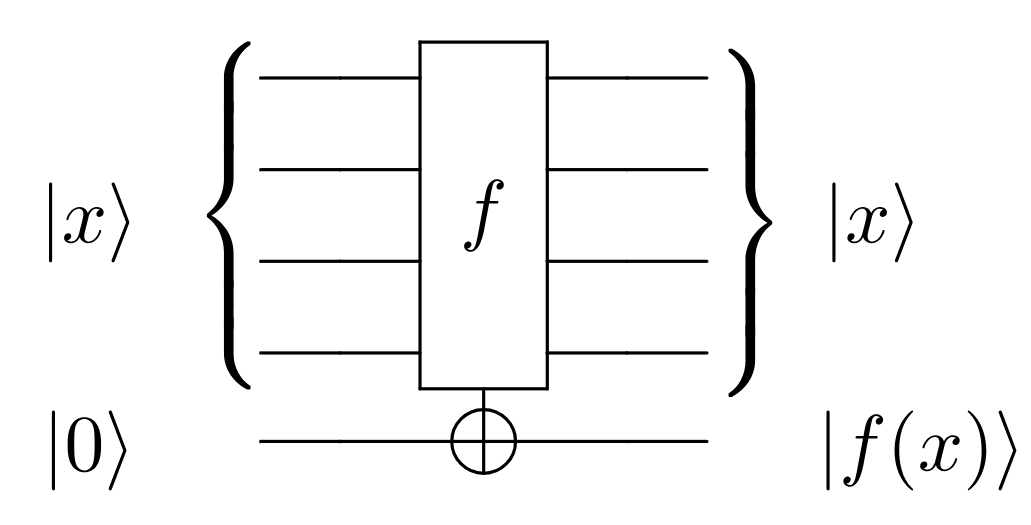

Seulement, cette fonction ne permet donc pas de modifier notre vecteur d'état $\left| s \right\rangle$, elle modifie seulement le qubit de sortie $\left| y \right\rangle$ : nous n'avons toujours aucune idée de quelle est la solution au problème.

On définit donc une fonction appelée "***Oracle***" et qui, à l'image de la Pythie de Delphes, révèle la solution $\omega$ "cachée dans la fonction $f$" (ie. $f(\omega)=1$).

Pour ce faire, on définit la porte quantique $U_\omega$ (l'Oracle), qui inversera le signe de la composante associée à $\omega$ dans le vecteur d'état, de telle sorte que :

$$\left| s \right\rangle=
\begin{bmatrix} x_1 \\ x_2 \\ \vdots \\ x_i \\ \vdots \\ x_n \end{bmatrix} 
\begin{matrix} \\ \\ \gets \omega \\ \\ \end{matrix} 
\quad\implies  \quad
U_\omega\left| s \right\rangle=
\begin{bmatrix} x_1 \\ x_2 \\ \vdots \\ -x_i \\ \vdots \\ x_n \end{bmatrix}
\begin{matrix} \\ \\ \gets \omega \\ \\ \end{matrix} $$

Si l'on reprend notre schéma du vecteur d'état $\left| s\right\rangle$ dans le plan $(O,\left| \xi\right\rangle, \left| \omega\right\rangle)$ où $\left| \xi \right\rangle=\frac{1}{\sqrt{N-1}}\sum_{n \neq \omega}\left| n \right\rangle$, l'application de l'oracle $U_\omega$ transforme donc le vecteur d'état par symétrie autour de l'axe des abscisses (orthogonal à l'axe $\omega$).

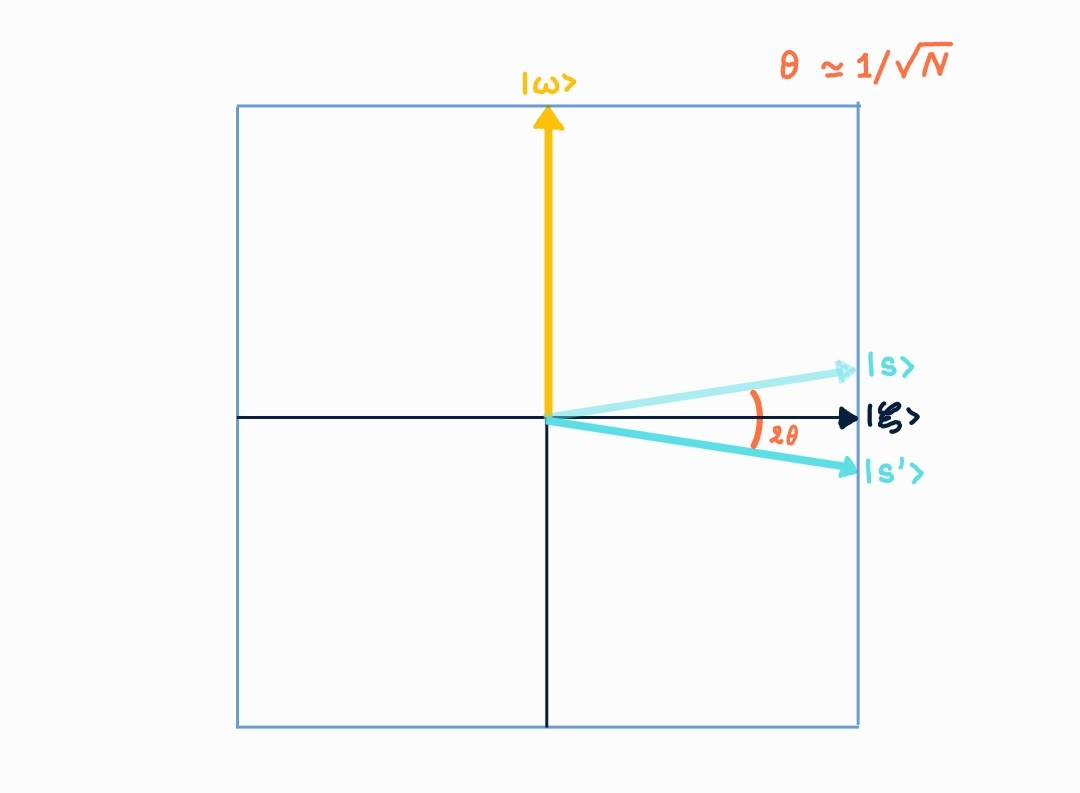

Explicitement, on peut donc représenter la porte $U_\omega$ par la matrice identité, où le signe de l'élément diagonal correspondant à la solution $\omega$ a été inversé :
$$\begin{matrix}
U_\omega\left| s \right\rangle=
\begin{bmatrix} x_1 \\ x_2 \\ \vdots \\ -x_i \\ \vdots \\ x_n \end{bmatrix}
\begin{matrix} \\ \\ \gets \omega \\ \\ \end{matrix}
& \implies & 
U_\omega=
\begin{bmatrix}
1 & 0 & \cdots  & 0 & \cdots  & 0 \\
0 & 1 & \cdots  & 0 & \cdots  & 0  \\
\vdots  &  & \ddots  & \vdots  &  & \vdots  \\
0 & \cdots & \cdots  & -1 & \cdots  & 0 \\
\vdots  & \vdots  &  & \vdots  & \ddots  & \vdots  \\
0 & 0 & \cdots  & 0 & \cdots  & 1
\end{bmatrix}
\begin{matrix} \\   \gets \omega \\ \end{matrix}
\end{matrix}$$

Soit, sachant qu'on ne connait pas la sortie $\omega$, mais seulement la fonction $f$ qui la trouve, on écrit $U_\omega$ :
$$\begin{matrix}
U_\omega=
\begin{bmatrix}
(-1)^{f(x_0)} & 0 & \cdots  & 0 \\
0 & (-1)^{f(x_1)} & \cdots  & 0 \\
\vdots  &  & \ddots  & \vdots  \\
0 & \cdots  & 0 & (-1)^{f(x_{2^n-1})}
\end{bmatrix}
& \text{ où, } &
f(x_i)= \left\{ \begin{array}{cl}
1 & \text{si } x_i = \omega\\
0 & \text{sinon}
\end{array} \right.
\end{matrix}$$

##### Former l'oracle $U_\omega$ à l'aide de portes quantiques

Contrairement à la fonction $f$, l'objectif de l'oracle n'est donc pas d'inverser le qubit de sortie, mais d'inverser une phase particulière du vecteur d'état : la composante correspondant à la solution $\omega$.

Il s'agit donc de faire passer le vecteur $\left| x \right\rangle$ à un vecteur $(-1)^{f(x)}\left| x \right\rangle$

Comme on l'a vu, si on applique la matrice $X$ à son vecteur propre $\left| - \right\rangle$, on obtient le *phase kickback* espéré : $X\left| - \right\rangle=-\left| - \right\rangle$.

Dans ce sens, si on initialise le qubit de sortie à l'état $\left| - \right\rangle$, on obtient la sortie $X^{f(x)}\left| - \right\rangle=(-1)^{f(x)}\left| - \right\rangle$ recherchée.

Ainsi, il suffit d'appliquer :
$$\left| x \right\rangle X^{f(x)}\left| - \right\rangle=(-1)^{f(x)}\left| x \right\rangle\left| - \right\rangle$$

Puis d'ignorer le bit de sortie $\left| - \right\rangle$. 

L'oracle s'écrit donc schématiquement :
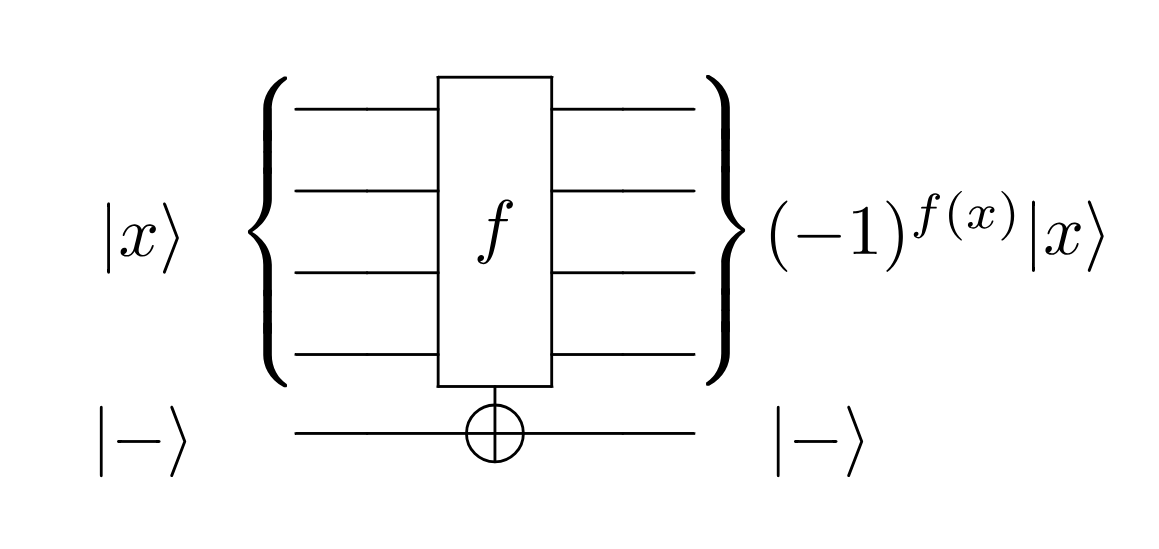

Une fois formé, on peut désormais l'appliquer à l'ensemble des qubits :

<>:3: SyntaxWarning: invalid escape sequence '\o'
<>:3: SyntaxWarning: invalid escape sequence '\o'
C:\Users\X1 Carbon\AppData\Local\Temp\ipykernel_26944\3498154365.py:3: SyntaxWarning: invalid escape sequence '\o'
  oracle.name = "Oracle - $U_\omega$"


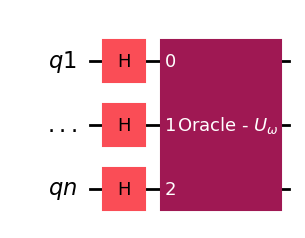

In [24]:
qc = QuantumCircuit(3)
oracle = qc.to_gate()
oracle.name = "Oracle - $U_\omega$"

Grover.append(oracle, [0,1,2])
Grover.draw('mpl')

Finalement, l'objectif de l'algorithme de Grover sera de rapprocher orthogonalement le vecteur d'état $\left| s\right\rangle$ à la direction $\left| \omega \right\rangle$.

Pour ce faire, on diffusera l'angle $2\theta$ généré par l'Oracle, jusqu'à être suffisament coolinéaire à l'axe de la solution $\left| \omega \right\rangle$, tel que :

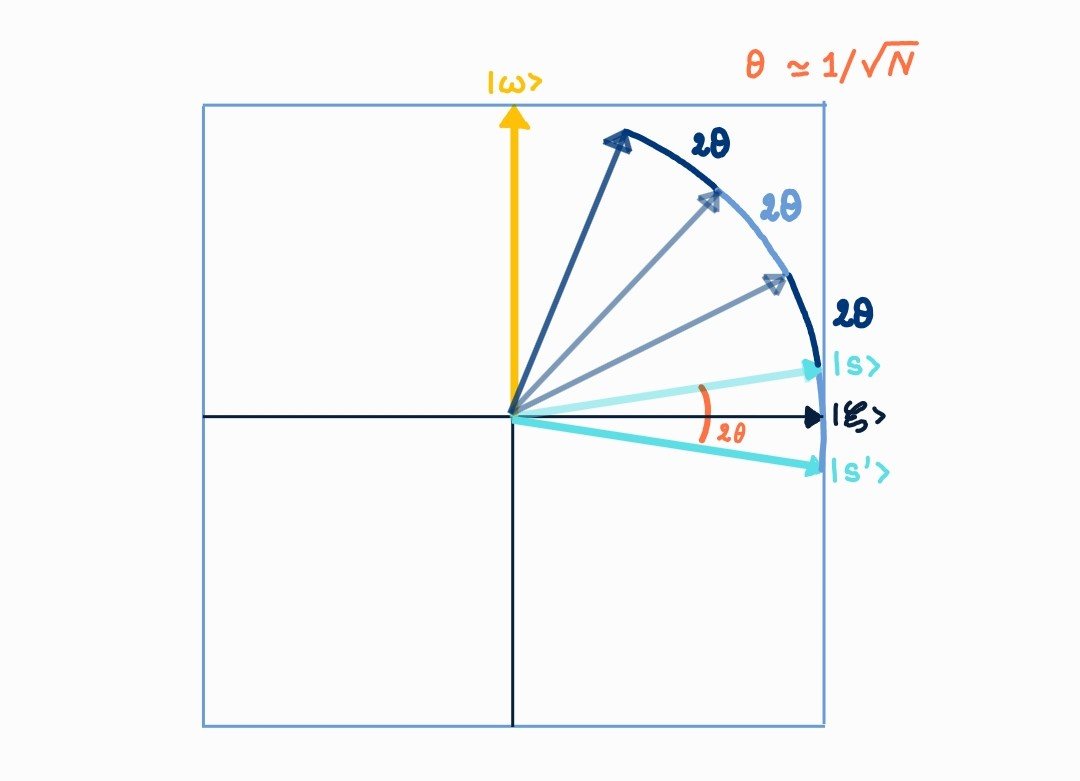

#### IV.B.3) Etape 3 : Diffusion

Concrètement, il faut donc effectuer une réflexion de $\left| s'\right\rangle$ autour de l'axe $\left| s\right\rangle$.

Pour rappel, pour effectuer une réflexion du vecteur $\left| s\right\rangle$ selon l'axe $\left| \xi \right\rangle$, nous avons inversé le signe de la composante de $\left| s\right\rangle$ orthogonale à $\left| \xi \right\rangle$.

Ainsi, pour effectuer une réflexion du vecteur $\left| s'\right\rangle$ selon l'axe $\left| s \right\rangle$, nous devrons inverser le signe **de toutes les composantes** de $\left| s'\right\rangle$ orthogonales à $\left| s \right\rangle$.

En effet, dans le premier cas, il existait une unique composante de $\left| s\right\rangle$ orthogonale à $\left| \xi \right\rangle$ : la composante correspondant à la solution $\left| \omega\right\rangle$ telle que $f(\left| \omega\right\rangle)=1$.

Pour trouver l'ensemble des composantes du vecteur $\left| s'\right\rangle$ orthogonales à $\left| s \right\rangle$, il faudra donc considérer $\left| s\right\rangle$ comme une direction de base.

Par exemple, considérer $\left| s\right\rangle$ la nouvelle orientation $\left| 0^n\right\rangle$.

Pour ce faire, on remarquera que $\left| s\right\rangle$ n'est qu'une superposition de tous les états de base, c'est-à-dire : $\left| s \right\rangle=H^{\otimes n}\left| 0^n \right\rangle$.

Dans ce sens, puisque la matrice $H$ est autoadjointe ($HH=I$) :
$$H^{\otimes n}\left| s \right\rangle=H^{\otimes n}H^{\otimes n}\left| 0^n \right\rangle=\left| 0^n \right\rangle$$

Il suffit donc d'appliquer un ensemble de portes Hadamard sur $\left| s\right\rangle$ pour retrouver le vecteur $\left| 0^n\right\rangle$. 

On applique donc un ensemble de porte Hadamard au vecteur $\left| s'\right\rangle$ de telle sorte que :
$$\left| s_H \right\rangle=H^{\otimes n}\left| s' \right\rangle=
\begin{bmatrix} x_0' \\ x_1' \\ \vdots  \\ x_{N-1}' \end{bmatrix}
\begin{matrix}
\gets \left| s \right\rangle \\ \\ \\ \\  \end{matrix}$$

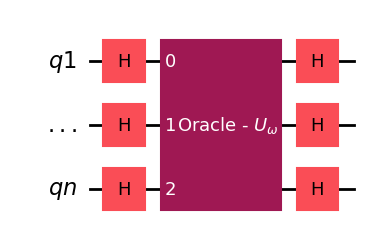

In [25]:
for i in range (3):
    Grover.h(i)
    
Grover.draw('mpl')

De cette manière, il ne reste plus qu'à appliquer une phase négative à tous les états orthogonaux à $\left| 0\right\rangle$ (tous les états orthogonaux à $\left| s\right\rangle$). C'est-à-dire :

$$\left( \left| 0 \right\rangle + \left| 1 \right\rangle + \dots  + \left| N \right\rangle \right)\rightarrow
\left( \left| 0 \right\rangle - \left| 1 \right\rangle - \dots - \left| N \right\rangle \right)$$

Cette opération revient donc à effectuer la réflexion suivante : $(2\left| 0 \right\rangle\left\langle 0 \right|-I)$ 

$\implies$ On conserve l'état $\left| 0 \right\rangle$ et on inverse le signe des autres états (orthogonaux à $\left| 0 \right\rangle$).

Comme on l'a vu, la porte $Z$ permet d'inverser le signe d'un état. Seulement, nous ne voulons pas appliquer la porte $Z$ à tous les états (ie. l'appliquer à tous les qubits), mais seulement à  l'état $\left| 0^n \right\rangle$.

Pour cibler un état donné dans l'application d'une porte, on utilise ce qu'on appelle des *contrôles* sur l'application de cette porte.

Un contrôle ne fait rien de plus que vérifier si le qubit auquel il est rattaché est à $1$.

Ainsi, la porte Controlled-Z ($CZ$) pour 2 qubits s'écrit : 
$$CZ = \begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 1& 0& 0\\
0& 0& 1 & 0 \\
0 & 0& 0 & -1
\end{pmatrix}
\begin{matrix}
\gets \left| 00 \right\rangle \\
\gets \left| 01 \right\rangle \\
\gets \left| 10 \right\rangle \\
\gets \left| 11 \right\rangle
\end{matrix}\begin{matrix} \\ \\ \\ \times (-1)\end{matrix}$$

Plus largement, on peut mettre des contrôles sur les $n$ qubits. La porte Multi-Controlled-Z ($MCZ$) s'écrit donc de la même manière :

$$CZ = \begin{pmatrix}
1 & \cdots  & 0 & 0 \\
0 & \ddots  & \vdots  & \vdots  \\
\vdots  & \ddots  & 1 & 0 \\
0 & \cdots  & 0 & -1
\end{pmatrix}
\begin{matrix}
\gets \left| 0^n \right\rangle \\ \vdots  \\
\gets \left| 1^{n-1}0 \right\rangle \\
\gets \left| 1^n \right\rangle
\end{matrix}\begin{matrix} \\ \\ \\ \\ \times (-1)\end{matrix}$$

Finalement, pour effectuer la réflexion $(2\left| 0 \right\rangle\left\langle 0 \right|-I)$, il faut :

* **Inverser tous les qubits** de toutes les composantes de sorte à ce que $\left| 0^n \right\rangle$ devienne l'état $\left| 1^n \right\rangle$ 

$\quad\implies$ porte $X$ sur l'ensemble des qubits
* **Inverser la phase** du vecteur $\left| 1^n \right\rangle$ 

$\quad\implies$ porte $MCZ$ sur l'ensemble des qubits

* **Réinverser les qubits** afin de retrouver l'état initial $\left| 1^n \right\rangle \rightarrow\left| 0 \right\rangle$ 

$\quad\implies$ porte $X$ sur l'ensemble des qubits

Soit :

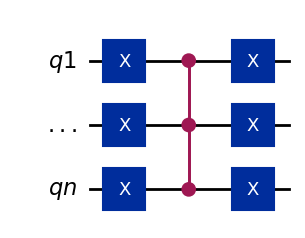

In [26]:
un = QuantumRegister(1, name="q1")
deux = QuantumRegister(1, name="...")
trois = QuantumRegister(1, name="qn")
qc = QuantumCircuit(un, deux, trois)

for i in range (3):
    qc.x(i)

mcz_gate = ZGate().control(2)
qc.append(mcz_gate, range(3))
  
for i in range (3):
    qc.x(i)
    
qc.draw('mpl')

Enfin, une fois que l'on a réalisé la réflexion de $\left| s_H\right\rangle$ autour de l'axe $\left| 0\right\rangle$ (soit celle de $\left| s' \right\rangle$ autour de $\left| s\right\rangle$), on remet le vecteur $\left| 0\right\rangle$ en position $\left| s\right\rangle$, à l'aide de portes Hadamard.

De cette manière, le diffuseur s'écrit donc :

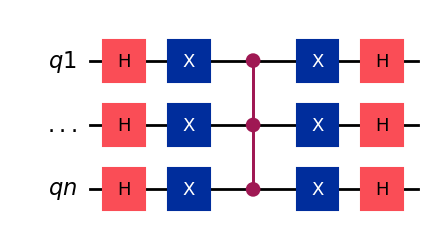

In [27]:
un = QuantumRegister(1, name="q1")
deux = QuantumRegister(1, name="...")
trois = QuantumRegister(1, name="qn")
qc = QuantumCircuit(un, deux, trois)

for i in range (3):
    qc.h(i)
    qc.x(i)

mcz_gate = ZGate().control(2)
qc.append(mcz_gate, range(3))
  
for i in range (3):
    qc.x(i)
    qc.h(i)
    
qc.draw('mpl')

#### IV.B.4) Algorithme de Grover complet

Finalement, l'algorithme de Grover peut se représenter par le circuit :

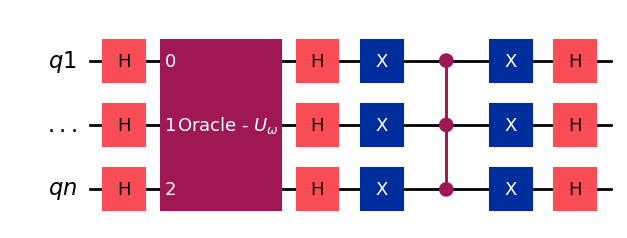

In [28]:
for i in range (3):
    Grover.x(i)

mcz_gate = ZGate().control(2)
Grover.append(mcz_gate, range(3))
  
for i in range (3):
    Grover.x(i)
    
for i in range (3):
    Grover.h(i)

Grover.draw('mpl')

### IV.C Implémentation de Grover sur Qiskit

Maintenant que nous avons compris le fonctionnement de l'algorithme de Grover, voyons comment Qiskit facilite son implémentation. Le framework propose une fonction clé en main qui encapsule toute la complexité de la construction de l'opérateur de Grover.

#### IV.C.1) La fonction `grover_operator()` de Qiskit

Qiskit fournit la fonction `grover_operator()` qui construit automatiquement l'opérateur de Grover $\mathcal{Q}$ à partir d'un oracle. Cette fonction est la **solution recommandée** par IBM (la classe `GroverOperator` étant dépréciée depuis Qiskit 2.1).

In [29]:
from qiskit.circuit.library import grover_operator

##### Construction d'un oracle par changement de phase

Avant d'utiliser `grover_operator()`, il faut donc construire un oracle qui marque les états solutions. 

Dans ce sens, on commence donc par créer une fonction `creer_oracle` qui marque l'ensemble des états marqués `etats_marques` à l'aide d'un changement de phase :

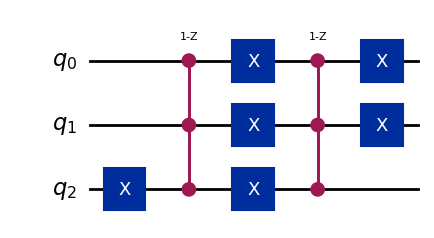

In [ ]:
from qiskit.circuit.library import MCMTGate, ZGate

def creer_oracle(etats_marques):
    
    if not isinstance(etats_marques, list):
        etats_marques = [etats_marques]
    
    num_qubits = len(etats_marques[0])
    oracle = QuantumCircuit(num_qubits)
    
    for etat_cible in etats_marques:
        etat_inverse = etat_cible[::-1]
        
        indices_zero = [i for i in range(num_qubits) if etat_inverse[i] == '0']
        
        if indices_zero:
            oracle.x(indices_zero)
        
        # Appliquer une porte Z multi-contrôlée
        oracle.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)
        
        if indices_zero:
            oracle.x(indices_zero)
    
    return oracle


# Marquer un seul état
oracle = creer_oracle("011")
# Marquer plusieurs états
oracle = creer_oracle(["011", "100"])

oracle.draw('mpl')

**Principe de fonctionnement** :

Pour marquer l'état $|011\rangle$ par exemple, la fonction applique :
1. Une/Des portes X qui transforment $|011\rangle$ en $|111\rangle$ (en inversant le premier qubit)
2. Une porte MCZ (Multi-Controlled-Z) qui applique une phase -1 à $|111\rangle$
3. Une/Des portes X qui défont la transformation : $-|111\rangle \rightarrow -|011\rangle$

Ainsi, seul l'état $|011\rangle$ reçoit une phase négative.

##### Utilisation de la fonction `grover_operator`

Ainsi, il ne reste plus qu'à appliquer la fonction `grover_operator()` qui s'occupe automatiquement de construire la séquence complète.

Elle applique donc, dans l'ordre :
1. l'oracle $\mathcal{S}_f$, qui marque les états solutions
2. l'inversion de la préparation des états ($H^{\otimes n}$)
3. la réflexion $\mathcal{S}_0$ autour de zéro
4. la restitution de la préparation d'état ($H^{\otimes n}$)

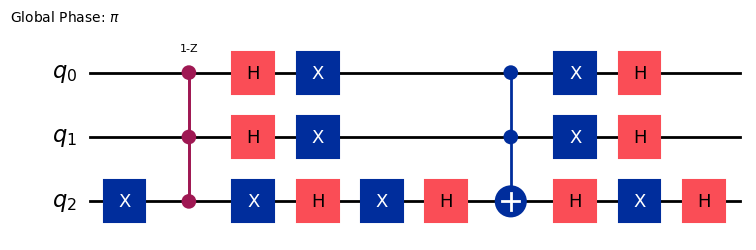

In [45]:
etat_marque = '011'
oracle = creer_oracle(etat_marque)

grover_op = grover_operator(oracle)

grover_op.draw('mpl')

**Pourquoi l'approche de Qiskit est optimale ?**
- Les portes multi-contrôlées (MCX) restent abstraites, ce qui permet au compilateur de choisir la meilleure décomposition selon le matériel cible
- Le circuit n'est pas encapsulé dans une porte opaque, ce qui facilite l'optimisation
- On observe de meilleures performances sur du matériel quantique réel

#### IV.C.2) Options de personnalisation de grover_operator()

La fonction `grover_operator()` offre plusieurs paramètres pour adapter l'algorithme à des cas d'usage avancés :

In [ ]:
grover_operator(
    oracle,                    # Oracle de phase (QuantumCircuit ou Statevector)
    state_preparation=None,    # Préparation d'état personnalisée (défaut: Hadamards)
    zero_reflection=None,      # Réflexion personnalisée autour de |0>
    reflection_qubits=None,    # Qubits sur lesquels appliquer la réflexion
    insert_barriers=False,     # Insérer des barrières pour visualisation
    name='Q'                   # Nom du circuit
)

**Exemple : Insertion de barrières**

Les barrières permettent de séparer visuellement les étapes de l'algorithme sans affecter le calcul :

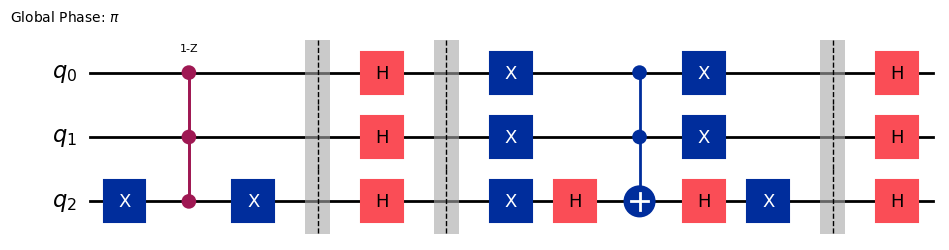

In [46]:
grover_op = grover_operator(oracle, insert_barriers=True)
grover_op.draw('mpl')

Le circuit affiché montre clairement : Oracle | Hadamards | Réflexion | Hadamards

##### Construction d'un circuit complet

Finalement, pour utiliser l'algorithme de Grover, il faut construire un circuit qui :
1. Initialise une superposition uniforme des états
2. Applique l'opérateur de Grover $k$ fois
3. Mesure les qubits

##### A. Calcul du nombre optimal d'itérations

Dans ce sens, il faut donc commencer par calculer le nombre d'applications $k$ de l'opérateur de Grover, qui dépend de l'angle $\theta = \arcsin\left(\sqrt{\frac{M}{N}}\right)$, où $M$ est le nombre de solutions parmi les $N = 2^n$ états possibles.

Pour rappel, le nombre $k$ d'itérations à réaliser est le nombre de fois qu'il faut répeter la diffusion de l'angle $\theta$ pour parcourir un quart de cercle, c'est-à-dire :

$$k = \left\lfloor \frac{\pi}{4\theta} \right\rfloor$$

On écrit donc la fonction qui calcule le nombre $k$ d'itérations à réaliser :


In [ ]:
import math

def nombre_iterations_optimal(nombre_solutions, nombre_qubits):
    N = 2 ** nombre_qubits
    M = nombre_solutions
    
    return math.floor(
        math.pi / (4 * math.asin(math.sqrt(M / N)))
    )

# Exemple : 1 solution parmi 8 états (3 qubits)
k_opt = nombre_iterations_optimal(1, 3)
print(f"Nombre optimal d'itérations : {k_opt}")

Nombre optimal d'itérations : 2


A noté que si l'on applique trop d'itérations, on dépasse l'angle optimal et donc on diminue la probabilité de succès. C'est pourquoi le calcul précis de $k$ est essentiel.

##### B. Assemblage du circuit

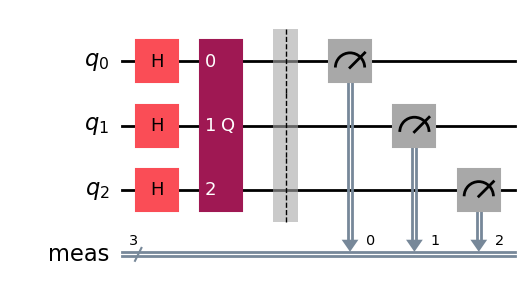

In [35]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import grover_operator

oracle = creer_oracle(["011", "100"])  
grover_op = grover_operator(oracle)

num_qubits = grover_op.num_qubits
nombre_solutions = 2
k_optimal = nombre_iterations_optimal(nombre_solutions, num_qubits)

circuit = QuantumCircuit(num_qubits)
circuit.h(range(num_qubits))
circuit.compose(grover_op.power(k_optimal), inplace=True)
circuit.measure_all()

circuit.draw('mpl')

Pour appliquer l'opérateur de Grover exactement $k$ fois, on utilise la méthode `.power(k)` de Qiskit. 

Mathématiquement, elle construit le circuit pour $\mathcal{Q}^k = \underbrace{\mathcal{Q} \circ \mathcal{Q} \circ \cdots \circ \mathcal{Q}}_{k \text{ fois}}$.

#### IV.C.3) Exécution sur un ordinateur quantique avec le Sampler

##### Note importante : Simulation ou Execution sur du matériel IBM Quantum réel

> *Pour exécuter sur du matériel IBM Quantum réel, il faut avoir un compte sur IBM Quantum Platform.*
>
> *Néanmoins, l'accès aux simulateurs locaux (comme AerSimulator) ne nécessite pas de compte.*
>
> *Nous présenterons donc comment éxecuter un circuit sur du matériel IBM Quantum réel, mais nous ferons une démonstration qu'avec le simulateur de la librairie* `qiskit_aer`.

##### A. Execution sur du matériel IBM Quantum réel

##### Qu'est-ce qu'une primitive ?

Qiskit Runtime introduit le concept de **primitives** : des interfaces standardisées pour exécuter des algorithmes quantiques. Il existe deux primitives principales :

- **Sampler** : pour obtenir des distributions de probabilité (échantillonnage)
- **Estimator** : pour calculer des valeurs d'espérance d'observables

Ici, pour l'algorithme de Grover, on veut mesurer les qubits et observer la distribution de probabilité sur les états de base. C'est donc un **problème d'échantillonnage**. Le Sampler est donc la primitive adaptée.

**Pourquoi utiliser les primitives ?**
- Abstraction du matériel : le même code fonctionne sur simulateur ou matériel réel
- Optimisations automatiques : gestion du bruit, mitigation d'erreurs
- Gestion simplifiée des jobs et résultats

##### 1. Préparation : transpilation

Avant l'exécution sur du matériel quantique réel, il est **impératif** de transpiler le circuit. La transpilation adapte le circuit abstrait aux contraintes du processeur quantique. Elle effectue :
1. **Décomposition des portes** : convertit en portes natives du processeur (typiquement : U, CX)
2. **Placement des qubits** : mappe les qubits logiques sur les qubits physiques selon la topologie
3. **Optimisation** : réduit la profondeur et le nombre de portes pour minimiser l'accumulation d'erreurs

Pour l'utiliser, il faut importer la méthode `generate_preset_pass_manager` de la librairie `qiskit.transpiler`.

In [ ]:
# Ne fonctionne pas sans compte sur IBM Quantum Platform

from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False)

pm = generate_preset_pass_manager(
    target=backend.target,
    optimization_level=3
)

circuit_transpile = pm.run(circuit)

print(f"Profondeur avant : {circuit.depth()}")
print(f"Profondeur après : {circuit_transpile.depth()}")

##### 2. Exécution avec le Sampler

In [ ]:
# Ne fonctionne pas sans compte sur IBM Quantum Platform

from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)
sampler.options.default_shots = 10_000

job = sampler.run([circuit_transpile])
result = job.result()
counts = result[0].data.meas.get_counts()

from qiskit.visualization import plot_distribution
plot_distribution(counts)

Le résultat `counts` est un dictionnaire où les clés sont les états mesurés (chaînes binaires) et les valeurs sont les nombres d'occurrences.

Sur un **simulateur parfait**, on observera des pics très marqués sur les états solutions. Sur du **matériel réel**, le bruit quantique élargira ces pics et créera des mesures parasites.

##### B. Simulation avec `qiskit_aer` : recherche de |101⟩ sur 3 qubits (`grover_operator`)

Recherche de l'état |101⟩ parmi 8 états
Nombre d'itérations : 2


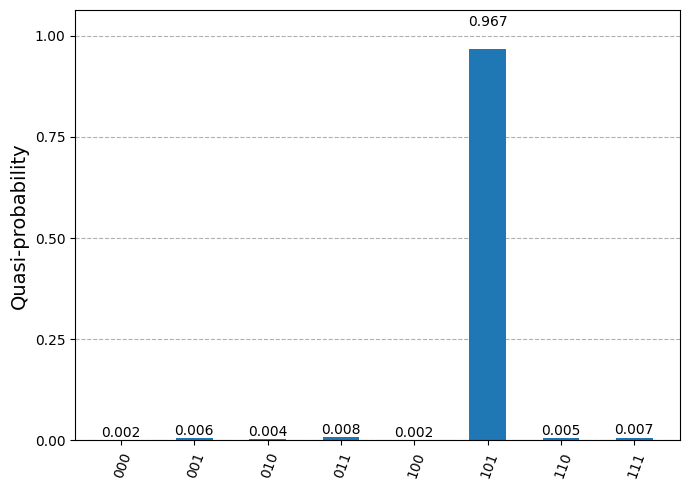

In [49]:
from qiskit_aer import Aer
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_distribution

etat_recherche = "101"
n_qubits = 3
nombre_solutions = 1

nb_shots = 1024

print(f"Recherche de l'état |{etat_recherche}⟩ parmi {2**n_qubits} états")

# Construire l'oracle avec la fonction creer_oracle()
oracle = creer_oracle(etat_recherche)

# Construire l'opérateur de Grover
grover_op = grover_operator(oracle, insert_barriers=True)

# Calculer le nombre optimal d'itérations
k = nombre_iterations_optimal(nombre_solutions, n_qubits)
print(f"Nombre d'itérations : {k}")

# Assembler le circuit complet
circuit = QuantumCircuit(n_qubits)
circuit.h(range(n_qubits))
circuit.compose(grover_op.power(k), inplace=True)
circuit.measure_all()


simulator = Aer.get_backend('statevector_simulator')
nc = transpile(circuit, simulator)
job = simulator.run(nc, shots = nb_shots)
result = job.result()
counts = result.get_counts()

plot_distribution(counts)

### IV.D. Quantique et compléxité  : la révolution ?

#### IV.D.1) Algorithme de Grover et complexité en temps

Pour étudier la complexité de l'algorithme de Grover, nous allons donc revenir sur les problèmes NP-complets, et plus particulièrement le problème du voyageur de commerce.

Pour pouvoir représenter l'ensemble des circuits à $\nu$ villes possibles, nous allons utiliser $(\nu+1)\times \text{log}_2(\nu)$ qubits, de sorte à ce que chacune des $(\nu+1)$ villes du circuit soit représentée par un indice binaire de taille $log_2(\nu)$ :

$$\begin{matrix}
\quad\quad\text{taille }(\nu+1)\times \text{log}_2(\nu)
\\ \left| s \right\rangle = 
\overbrace{\left[ \underbrace{q_{0,1} \cdots q_{0,\text{log}_2(\nu)}} \,\,q_{1,1} \cdots q_{1,\text{log}_2(\nu)} \,\, \underbrace{q_{\nu,1} \cdots q_{\nu,\text{log}_2(\nu)}} \right]}\\
\begin{matrix}
 &&& 1^\text{ère}\text{ ville}&& &&&&&  & & \text{dernière}\text{ ville}
\end{matrix}
\end{matrix}, \quad\text{avec } \nu = \text{nombre de ville}$$

Pour rappel, dans un algorithme de résolution dans un ordinateur classique, trouver la réponse $\omega$ au TSP, demande de parcourir toutes les $N=2^{\nu.log_2(\nu)}$ instances, pour tester si elles sont vérifiées à l'aide de la fonction de vérification $f$. 

L'algorithme classique est donc en $O(N)$.

Pour un exemple :
* Avec **4** villes, il y a $N=2^{4\times 2}=256$ instances possible, donc **16** tests.
* Avec **10** villes, il y a $N=2^{10\times 4}=10^{12}$ instances possible, donc **1 million de million** de tests en moyenne.
* Avec **20** villes, il y a $N=2^{20\times 5}\simeq 10^{30}$ instances possible, donc plus d'**1 milliard de milliard de milliard** de tests en moyenne.

On comprend donc pourquoi le problème du voyageur de commerce devient rapidement irrésolvable sur un ordinateur classique (ou plutôt résolvable après un très grand lapse de temps).

Mais dans un ordinateur quantique, grâce à l'état de superposition, on peut représenter toutes les séquences de bits d'une longueur fixée en même temps.

Cependant, comme on l'a vu, contrairement à beaucoup d'idées reçues qui peuvent exister autour de l'informatique quantique, cela ne signifie pas que la fonction de recherche définie plus haut est en $O(1)$. 

En effet, l'algorithme de Grover que l'on vient de voir et qui permet de répondre à de tels problèmes, doit réaliser la même réflexion $2\theta=\frac{2}{\sqrt{N}}$ $\frac{\pi}{4}$ fois (*ie. sur un quart de cercle*) pour trouver la solution.

L'algorithme de résolution quantique, est donc en $O(\sqrt{N})$.

Pour reprendre notre exemple :
* Avec **4** villes, $\sqrt{N}\simeq\sqrt{256}= 16$, donc **16** tests à réaliser.
* Avec **10** villes, $\sqrt{N}\simeq\sqrt{10^{12}}=10^{6}$, donc **1 million** de tests à réaliser.
* Avec **20** villes, $\sqrt{N}\simeq\sqrt{10^{30}}= 10^{15}$, donc **1 million de milliards** de tests à réaliser.

Le gain est donc clairement non négligeable mais encore très loin d'un gain exponentiel $\left( \ln(10^{30})=69\right)$.

Seulement, en 1994, les chercheurs Bennett, Bernstein, Brassard et Vazirani ont prouvé qu'une résolution quantique d'un tel algorithme ne pourrait pas être moins complexe que $O(\sqrt{N})$. 

Au maximum, on ne peut donc améliorer cette fonction que d'un gain quadratique par rapport à l'algorithme classique. Soit, que l'algorithme quantique de cette fonction n'atteindra jamais un gain exponentiel.

$$\text{Complexité Résolution NP (quantique)} \ge O(\sqrt{N}) \gt O(\small\ln(\small N))$$

#### IV.D.2) Algorithme de Grover : Et la complexité en espace ?

Si l'amélioration de la complexité en temps de l'algorithme de Grover pour résoudre le problème du TSP décisionnel n'est "que" quadratique, la complexité en espace de cet algorithme pose de nombreux problèmes.

En effet, en informatique quantique, les développeurs sont généralement très limités en terme de nombre de qubits disponibles pour réaliser leur algorithme. La limite est aujourd'hui fixée à environ 50 qubits, avant que les erreurs physiques ne viennent trop perturber le résultat.

Ainsi, on pourrait penser que la limite de nombre de ville pour la résolution du TSP avec l'algorithme de Grover est limité à $n=12$ villes. 
$$\text{Nombre de qubits }=n.\text{log}_2(n)=12\times 4 = 48\lt 50$$

Seulement, ce serait oublier la partie du chapitre que nous avons laissé de côté :

> S'il est possible de créer une fonction $f$ qui permette de vérifier si une solution répond à un problème spécifique **à partir de portes logiques** (ce qui a été démontré pour les problèmes NP), alors il est possible de recréer cette fonction **à partir de portes quantiques**.

Ce qui constitue le plus gros poids pour la complexité en espace de l'algorithme de Grover en quantique pur, est en fait la fonction de vérification cachée dans l'oracle.

##### Traduire le vérificateur en quantique : N'utiliser que des portes réversibles

Pour rappel, la fonction de vérification du problème du TSP décisionnel s'écrit :


In [ ]:
def verifier_TSP_decision(graph, cycle, K):

    if cycle[0] != cycle[-1]:
        return False

    unique_nodes = cycle[:-1]
    if len(unique_nodes) != len(set(unique_nodes)):
        return False

    if set(unique_nodes) != set(graph.keys()):
        return False

    cost = 0
    for u, v in zip(cycle, cycle[1:]):
        if v not in graph[u]:
            return False  # arête inexistante
        cost += graph[u][v]

    return cost <= K

Puisque cette fonction est écrit en langage de haut niveau (Python), il peut paraitre simple et rapide de la réaliser sur un ordinateur quantique. 

Mais ce serait oublier que pour réaliser cette fonction en quantique, nous ne pouvons qu'effectuer des manipulations de qubits à l'aide de portes quantiques **réversibles**. 

Ainsi, si l'on souhaite traduire la condition *"le circuit commence et se termine par la même ville"* : 

In [ ]:
if cycle[0] != cycle[-1]:
    return False

Nous devons utiliser la fonction qui compare le premier et le dernier block du vecteur d'état :
$$\begin{matrix}
\quad\quad\text{taille }(\nu+1)\times \text{log}_2(\nu)
\\ \left| s \right\rangle = 
\overbrace{\left[ \underbrace{q_{0,1} \cdots q_{0,\text{log}_2(\nu)}} \,\,q_{1,1} \cdots q_{1,\text{log}_2(\nu)} \,\, \underbrace{q_{\nu,1} \cdots q_{\nu,\text{log}_2(\nu)}} \right]}\\
\begin{matrix}
 &&& 1^\text{ère}\text{ ville}&& &&&&&  & & \text{dernière}\text{ ville}
\end{matrix}
\end{matrix}, \quad\text{avec } \nu = \text{nombre de ville}$$

C'est-à-dire qui compare une à une chaque paire de qubits de chacun des blocks et qui retourne vrai si une des paires est inégale :
$$(\text{block first}[0] \, \neq \, \text{block last}[0])\text{ OU }\cdots \text{ OU }(\text{block first}[b] \, \neq \, \text{block last}[b])$$

Pour réaliser l'opération $\text{block first}[k] \neq \text{block last}[k]$ il suffit d'utiliser une porte XOR : ```block_first[k] XOR block_last[k]``` 

Pour stocker le résultat de la comparaison, on applique une porte X sur la sortie lorsque : ```block_first[k] XOR block_last[k] = 1``` 

Pour effectuer une porte XOR sur deux qubits, il suffit d'utiliser la **porte Toffoli** $CCX$. Cette porte prend deux qubits en entrée, vérifie si les deux sont à 1, et applique une porte $X$ sur la sortie lorsque c'est le cas.

Ici, on utilise des portes $X$ pour cibler les état '10' et '01', afin d'appliquer $X$ sur la sortie si et seulement si le premier bit est à 1 et le second est à 0, ou si le premier bit est à 0 et le second est à 1.

Dans ce sens, la comparaison de deux qubits ($\text{block first}[k] \neq \text{block last}[k]$) s'écrit :

In [ ]:
def x(q): return f"x {q};"
def cx(a,b): return f"cx {a}, {b};"
def ccx(a,b,c): return f"ccx {a}, {b}, {c};"

def xor(a, b, sortie):
    L = []
    
    #a=1, b=0 -> X(b)
    L.append(x(b))
    L.append(ccx(a, b, sortie))
    L.append(x(b))
    
    # a=0, b=1 -> X(a)
    L.append(x(a))
    L.append(ccx(a, b, sortie))
    L.append(x(a))
    
    return L

Seulement, lorsque la longueur du bloc est supérieure à 1 (lorsque nous avons plus de $2$ villes), il faut effectuer l'opération :
$$(\text{block first}[0] \, \text{ XOR } \, \text{block last}[0])\text{ OU }\cdots \text{ OU }(\text{block first}[b] \, \text{ XOR } \, \text{block last}[b])$$

Le problème étant que, lorsque l'on effectue un algorithme à l'aide de portes quantiques, il faut faire attention à ce que chaque opérations soit réversible. C'est-à-dire qu'il n'est pas possible d'utiliser une même sortie pour effectuer un ensemble de contrôle.

En effet, sinon, le qubit de sortie ne nous permettrait pas de savoir quelles portes contrôles ont été activées. On ne pourrait donc plus savoir quel était l'état du vecteur d'état avant l'application de ces portes, et nous briserions le principe essentiel de reversibilité dans l'informatique quantique.

Il faut donc stocker au moins les $(b-1)$ calculs intermédiaires, à l'aide de $(b-1)$ qubits supplémentaires, que l'on appelle des ancillas.

Ensuite, il faut comparer ces $(b-1)$ ancillas pour vérifier si l'une d'elle est égale à 1.

Pour ce faire, on utilise une porte $\text{Multi-CX}$, qui utilise elle même $(b-2)$ ancillas supplémentaires pour assurer la réversibilité de l'opération :

In [ ]:
def multi_cx(controls, target, anc):
    if (len(controls) - 2) > len(anc):
            raise ValueError("Pas assez d'ancilla pour effectuer une bCX.")
        
    L = []
    b = len(controls)
        
    # Controlled-X classique
    if b == 0:
        L.append(x(target))
        return L
    if b == 1:
        L.append(cx(controls[0], target))
        return L
    if b == 2:
        L.append(ccx(controls[0], controls[1], target))
        return L
        
    # Multi-controlled X avec ancillas
    L.append(ccx(controls[0], controls[1], anc(0)))
        
    for t in range(2, b-1):
        prev_anc = t - 2
        cur_anc = t - 1
        L.append(ccx(controls[t], anc(prev_anc), anc(cur_anc)))
    # dernière étape: controls[b-1], anc_prev -> target
    L.append(ccx(controls[t], anc(prev_anc), target))
        
    # Uncompute ancillas
    for t in reversed(range(2, b-1)):
        prev_anc = t - 2
        cur_anc = t - 1
        L.append(ccx(controls[t], anc(prev_anc), anc(cur_anc)))
    L.append(ccx(controls[t], anc(prev_anc), target))                
                
    # Uncompute première ancilla
    L.append(ccx(controls[0], controls[1], anc(0)))
    return L

Ainsi, pour réaliser le test :

In [ ]:
if cycle[0] != cycle[-1]:
    return False

tout en respectant le principe de la réversibilité, nous devons ajouter $(b-1)+(b-2)=2\text{log}_2(\nu)-3$ qubits à notre circuit.

Finalement, le test en quantique s'écrit :

In [ ]:
def diff_block(program, block_first, block_last, anc, anc_mcx, q_output): 
    
    b = len(block_first)
    
    # block_first XOR block_last
    for k in range(b):
        program.append(xor(block_first[k], block_last[k], anc[k]))
        
    for k in range(b):
        program.append(x(anc[k]))
        
    program.append(multi_cx(anc, q_output, anc_mcx))

    for k in range(b):
        program.append(x(anc[k]))

##### Matrice de distance quantique

Plus largement, il existe un plus grand problème pour la traduction de la fonction de vérification en quantique pure. En effet, cette fonction prend en paramètre un graphe : une matrice de taille $n\times n$ contenant le cout de déplacement entre chaque ville.

Pour traduire une telle matrice en quantique, il faut ajouter à notre circuit :
* $2\times \text{log}_2(\nu)$ qubits, pour représenter l'ensemble des adresses $[i][j]$
* $2\times (\text{log}_2(\nu)-1)$ ancillas, pour stocker les résultats intermédiaires
* $V$ qubits, pour stocker les coûts de déplacement, pour des valeurs comprise entre $0$ et $2^V$

Par exemple, si l'on considère la matrice de distance suivante, où : 
* $\nu=4$ villes
* Les cout de déplacement sont compris entre $0$ et $62\lt 2^{6}$

In [ ]:
from random import randint, seed
from math import ceil, log2, sqrt
seed(2025)

n = 4 # nombre de villes

# cout = distance euclidienne * poids aléatoire entre 1 et 2.25

max_coord = 20
max_weight_num = 1000
max_weight_den = 450
# max_weight = max_weight_num / max_weight_den = 2.25

val_max = int(np.sqrt(2) * max_coord * (max_weight_num / max_weight_den))

def gen_points(n):
    list_points = []
    for _ in range(n):
        x = randint(0, max_coord)
        y = randint(0, max_coord)
        list_points.append((x, y))
    return list_points

def create_weight_matrix(n, points):
    matrix = np.zeros((n, n), dtype=int)
    for i in range(n):
        for j in range(n):
            if i != j:
                p1 = points[i]
                p2 = points[j]
                weight = randint(max_weight_den, max_weight_num) / max_weight_den 
                cout = int(sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2) * weight)
                matrix[i][j] = cout
    return matrix

points = gen_points(n)
distance_matrix = create_weight_matrix(n, points)
print("~~~~~ Matrice de distances : ~~~~~")
print(distance_matrix)
print(f"\n==>  Valeurs entre 0 et {val_max}\n")

~~~~~ Matrice de distances : ~~~~~
[[ 0 24 28 22]
 [24  0 28 24]
 [20 19  0 10]
 [35 24 13  0]]

==>  Valeurs entre 0 et 62



C'est-à-dire que l'on cherche ici à résoudre le problème du TSP :

"Existe-t-il un circuit qui passe une fois et une seule par chacune des villes pour un coût $\le k$ ?", sur le graphe :

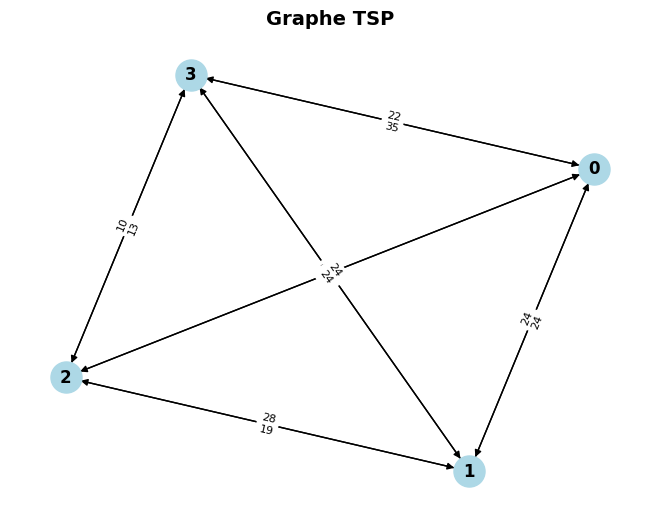

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

nodes = [i for i in range(n)]
edges = [(i, j) for i in range(n) for j in range(n) if i != j]

G = nx.DiGraph()
G.add_nodes_from(nodes)
G.add_edges_from(edges)

edge_labels = {}
for i in range(n):
    for j in range(i+1,n):
        edge_labels[(i, j)] = f"{int(distance_matrix[i, j])}\n{int(distance_matrix[j,i])}"
        
pos = nx.spring_layout(G, seed=0)
    
nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=500, font_weight="bold")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
plt.title("Graphe TSP", fontsize=14, fontweight='bold')

plt.show()

Alors la matrice de distance quantique comporte :
* $2\times \text{log}_2(4) = 4$ qubits, pour représenter l'ensemble des adresses $[i][j]$
* $2\times (\text{log}_2(4)-1) = 2$ ancillas, pour stocker les résultats intermédiaires
* $6$ qubits, pour stocker les coûts de déplacement, pour des valeurs comprise entre $0$ et $63$

Par dessus cela, elle s'écrit :

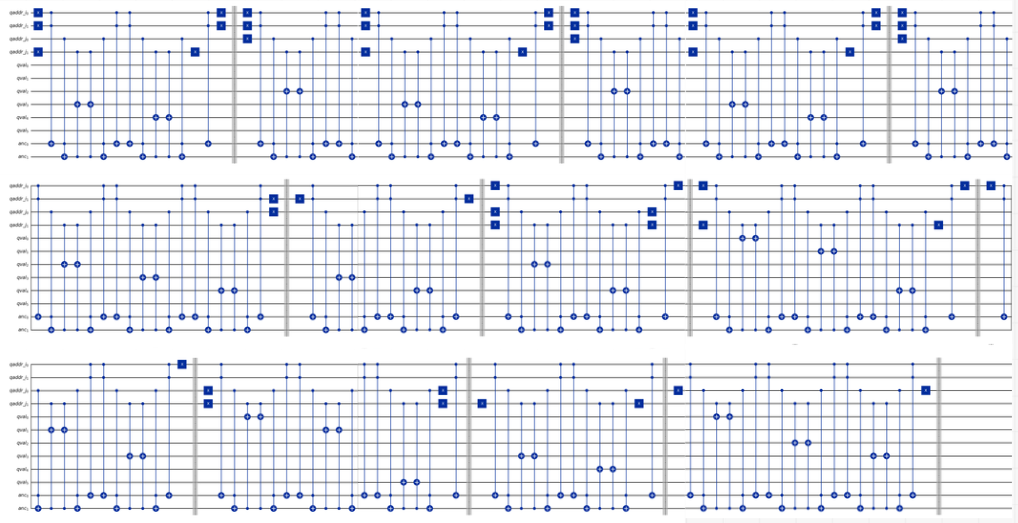

En conclusion, on peut donc voir que l'informatique quantique offre un paradigme très intéressant pour résoudre des problèmes plus efficacement notamment grâce à la superposition. Mais les algorithmes comme l'algorithme de Grover présentent rapidement leurs limites en terme de complexité en espace.

Cependant, l'informatique quantique offre bien d'autres solutions pour résoudre des problèmes d'optimisation. C'est pourquoi nous allons donc désormais explorer la résolution du problème du TSP à l'aide d'algorithmes QUBO.